In [2]:
import bacco
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [3]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [4]:
%load_ext autoreload
%autoreload 2

### Load the Zoom

In [228]:
#base = "/cosmos_storage/data_sharing/tmp_resims/1080-A/level4/haloes_10/hydro_output/"
base = "/cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

zoom = bacco.Simulation(basedir=base, halo_file="groups_009/fof_subhalo_tab_009", dm_file="snapdir_009/snapshot_009", sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False)

2024-07-09 18:23:41,738 bacco.sims : Initialising simulation Default
2024-07-09 18:23:41,739 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/snapdir_009/snapshot_009
2024-07-09 18:23:41,741 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/snapdir_009/snapshot_009


2024-07-09 18:23:42,022 bacco.sims : ...done in 0.00782 s


### Load the Original Sim

In [10]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=264)
mtng.fof['halo_pos'][:,0] = (mtng.fof['halo_pos'][:,0] - 125) % 500
mtng.sub['pos'][:,0] = (mtng.sub['pos'][:,0] - 125) % 500

2024-07-09 16:31:13,158 bacco.sims : Initialising simulation Default
2024-07-09 16:31:13,159 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-09 16:31:13,161 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-09 16:31:13,164 bacco.sims : ...done in 0.00588 s


2024-07-09 16:31:13,166 bacco.sims : Reading 98233510 items for GroupPos
2024-07-09 16:31:19,128 bacco.sims : Reading 90246895 items for SubhaloPos


### Let's work in a specific region

We will focus on one of the zoom halos

In [118]:
center = zoom.fof['halo_pos'][0]

In [119]:
L_p = 20
z_slab = 20
xmin = np.array([center[0]-L_p/2,center[1]-L_p/2,center[2]-z_slab/2])

shift = np.array([76,26,50]) * L_p/512 # n=0
#shift = np.array([44,50,13]) * L_p/512 # n=1
#shift = np.array([-3,50,-25]) * L_p/512 # n=2
#shift = np.array([50,65,60]) * L_p/512 # n=3
#shift = np.array([86,18,70]) * L_p/512 # n4

mtng_sel = np.where( (mtng.fof['halo_pos'][:,0]+shift[0]>(center[0]-L_p/2)) & (mtng.fof['halo_pos'][:,0]+shift[0]<(center[0]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,1]+shift[1]>(center[1]-L_p/2)) & (mtng.fof['halo_pos'][:,1]+shift[1]<(center[1]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,2]+shift[2]>(center[2]-z_slab/2)) & (mtng.fof['halo_pos'][:,2]+shift[1]<(center[2]+z_slab/2)) &\
                     (mtng.fof['halo_m200b']>50))[0]

In [230]:
zoom_sel = np.where( (zoom.dm['pos'][:,0]>(center[0]-L_p/2)) & (zoom.dm['pos'][:,0]<(center[0]+L_p/2)) &\
                     (zoom.dm['pos'][:,1]>(center[1]-L_p/2)) & (zoom.dm['pos'][:,1]<(center[1]+L_p/2)) &\
                     (zoom.dm['pos'][:,2]>(center[2]-z_slab/2)) & (zoom.dm['pos'][:,2]<(center[2]+z_slab/2)) )[0]

zoom_grid = bacco.statistics.compute_mesh(pos=zoom.dm['pos'][zoom_sel] - xmin[np.newaxis,:], box=L_p, ngrid=512)

2024-07-09 18:24:21,338 bacco.sims : Read data for 552285/4415360 particles...
2024-07-09 18:24:21,396 bacco.sims : Read data for 552285/4415360 particles...
2024-07-09 18:24:21,398 bacco.sims : Read data for 531913/4415360 particles...
2024-07-09 18:24:21,451 bacco.sims : Read data for 531913/4415360 particles...
2024-07-09 18:24:21,453 bacco.sims : Read data for 556641/4415360 particles...
2024-07-09 18:24:21,511 bacco.sims : Read data for 556641/4415360 particles...
2024-07-09 18:24:21,514 bacco.sims : Read data for 548950/4415360 particles...


/cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/snapdir_009/snapshot_009.0.hdf5


2024-07-09 18:24:21,568 bacco.sims : Read data for 548950/4415360 particles...
2024-07-09 18:24:21,570 bacco.sims : Read data for 556130/4415360 particles...
2024-07-09 18:24:21,626 bacco.sims : Read data for 556130/4415360 particles...
2024-07-09 18:24:21,628 bacco.sims : Read data for 564338/4415360 particles...
2024-07-09 18:24:21,684 bacco.sims : Read data for 564338/4415360 particles...
2024-07-09 18:24:21,686 bacco.sims : Read data for 562467/4415360 particles...
2024-07-09 18:24:21,742 bacco.sims : Read data for 562467/4415360 particles...
2024-07-09 18:24:21,745 bacco.sims : Read data for 542636/4415360 particles...
2024-07-09 18:24:21,799 bacco.sims : Read data for 542636/4415360 particles...
2024-07-09 18:24:21,863 bacco.sims :  DM loading done in 0.527 sec


In [231]:
del sel_pos

shift = np.array([76,26,50]) * L_p/512 # n=0
#shift = np.array([44,50,13]) * L_p/512 # n=1
#shift = np.array([-3,50,-25]) * L_p/512 # n=2
#shift = np.array([80,35,60]) * L_p/512 # n=3
#shift = np.array([86,18,70]) * L_p/512 # n4

sel_pos = (mtng.fof['halo_pos'][mtng_sel]-xmin[np.newaxis, :]-shift[np.newaxis, :])/L_p * 512

In [232]:
mtng.sub['pos'][mtng_ind_cen[0][0]]

array([ 33.26622, 397.25497, 461.00705], dtype=float32)

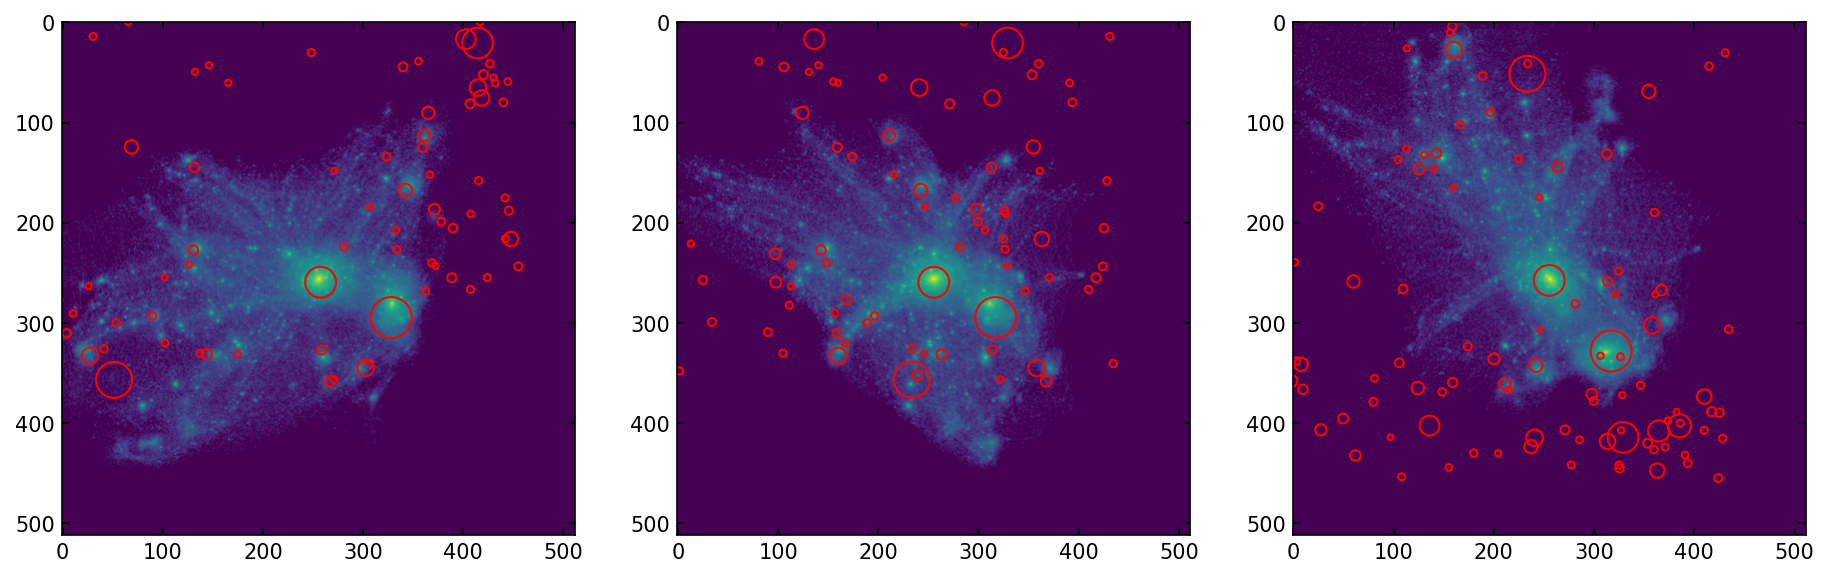

In [233]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(15,5))

ax[0].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=2)))
ax[1].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=1)))
ax[2].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=0)))

for i in range(sel_pos.shape[0]):
    circle = plt.Circle((sel_pos[i,1],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    ax[0].add_artist(circle)
    circle = plt.Circle((sel_pos[i,2],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    ax[1].add_artist(circle)
    circle = plt.Circle((sel_pos[i,2],sel_pos[i,1]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    ax[2].add_artist(circle)

#### Cross-match halos in the this region

In [123]:
dist, ind = bacco.utils.crossmatch([zoom.fof['halo_pos'][0]], (mtng.fof['halo_pos'][mtng_sel]-shift[np.newaxis, :]) % 500, max_distance=0.3, boxsize=500.000001)

#### Let's get their central galaxy

In [167]:
mtng_ind_cen = np.where((mtng.sub['parent_halo']['index']==mtng_sel[ind]) &  (mtng.sub['central']==True) )
mtng_ind_sat = np.where((mtng.sub['parent_halo']['index']==mtng_sel[ind]) &  (mtng.sub['central']==False) )

In [133]:
zoom_ind_cen = np.where((zoom.sub['parent_halo']['index']==0) &  (zoom.sub['central']==True) )
zoom_ind_sat = np.where((zoom.sub['parent_halo']['index']==0) &  (zoom.sub['central']==False) )

2024-07-09 17:03:38,583 bacco.sims : Reading 2872 items for SubhaloPos
2024-07-09 17:03:38,592 bacco.sims : Reading 2872 items for SubhaloVel
2024-07-09 17:03:38,602 bacco.sims : Reading 2872 items for SubhaloLen
2024-07-09 17:03:38,611 bacco.sims : Reading 5188 items for GroupLen
2024-07-09 17:03:38,619 bacco.sims : Reading 5188 items for Group_M_Crit200
2024-07-09 17:03:38,627 bacco.sims : Reading 5188 items for Group_M_Crit200
2024-07-09 17:03:38,634 bacco.sims : Reading 5188 items for GroupNsubs
2024-07-09 17:03:38,642 bacco.sims : Reading 5188 items for halo_firstsub
2024-07-09 17:03:38,697 bacco.sims :  saved sub_hdata


In [178]:
mstell_zoom = zoom.sub['MassType'][:,4][zoom_ind_cen[0]]
mstell_mtng = mtng.sub['MassType'][:,4][mtng_ind_cen[0]]

In [179]:
print(mstell_mtng, mstell_zoom)

[61.17987] [61.711155]


### Now we have to load the trees

In [226]:
with h5py.File("/cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/groups_009/subhalo_prog_009.0.hdf5", 'r') as f:
    print(f['Subhalo'].keys())
    print(f['Subhalo']['SubhaloNr'][()])
    print(f['Subhalo']['FirstProgSubhaloNr'][()])

<KeysViewHDF5 ['FirstProgSubhaloNr', 'NextDescSubhaloNr', 'ProgSubhaloNr', 'SubhaloNr']>
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105]
[   0    1    2    4    3    8    6    7    5   11    9   12   10   14
  754   16   18  871  931   19   15 1050   23   21  929   24   25 1320
   28   26   32 1340 1066 1338 1246 1202   34 1302   27   33 1586 1532
 1073   30   29 1262  755 1976   38   37 1874   39 1403   46   41  756
   45 1540   44 2043 1691 2082   48 2051   47   35 1969 2531 1940  930
 2469 2491   42   55   70 2078   68 2035   67 1938   61 2326   62 2146
   -1 2194   36   82   58 1074  933 2133   49 3072 258

In [217]:
moi_zoom = zoom.sub['subhalo_stellar_MOI'][zoom_ind_cen[0]][0]
moi_mtng = mtng.sub['subhalo_stellar_MOI'][mtng_ind_cen[0]][0]

In [218]:
s_zoom = np.zeros((3,3))
s_zoom[0,0] = moi_zoom[0]
s_zoom[0,1] = moi_zoom[1]
s_zoom[0,2] = moi_zoom[2]
s_zoom[1,1] = moi_zoom[3]
s_zoom[1,2] = moi_zoom[4]
s_zoom[2,2] = moi_zoom[5]
s_zoom[1,0] = s_zoom[0,1]
s_zoom[2,0] = s_zoom[0,2]
s_zoom[1,2] = s_zoom[2,1]

s_mtng = np.zeros((3,3))
s_mtng[0,0] = moi_mtng[0]
s_mtng[0,1] = moi_mtng[1]
s_mtng[0,2] = moi_mtng[2]
s_mtng[1,1] = moi_mtng[3]
s_mtng[1,2] = moi_mtng[4]
s_mtng[2,2] = moi_mtng[5]
s_mtng[1,0] = s_mtng[0,1]
s_mtng[2,0] = s_mtng[0,2]
s_mtng[1,2] = s_mtng[2,1]

In [219]:
np.trace(s_mtng@s_zoom) / np.sqrt( np.trace(s_mtng@s_mtng) * np.trace(s_zoom@s_zoom) )

0.9299541261822105

In [201]:
eig_zoom

(array([0.83546849, 1.01563249, 1.08112812]),
 array([[ 0.91405544, -0.00697629,  0.40552927],
        [-0.01662907, -0.99965595,  0.0202846 ],
        [ 0.40524823, -0.02528482, -0.91385696]]))

In [202]:
eig_mtng

(array([0.58306854, 1.69148092, 1.81810906]),
 array([[ 0.93635051,  0.02128272, -0.35042083],
        [ 0.08632803,  0.95355336,  0.28858875],
        [ 0.34028692, -0.30047137,  0.89102288]]))

In [75]:
m_sub_zoom = 1e10 * zoom.sub['MassType'][zoom_sub_sel,4][i_clean]
m_sub_mtng = 1e10 * mtng.sub['MassType'][mtng_sub_sel,4][ind[i_clean]]

Text(0, 0.5, '$M_{Zoom}$')

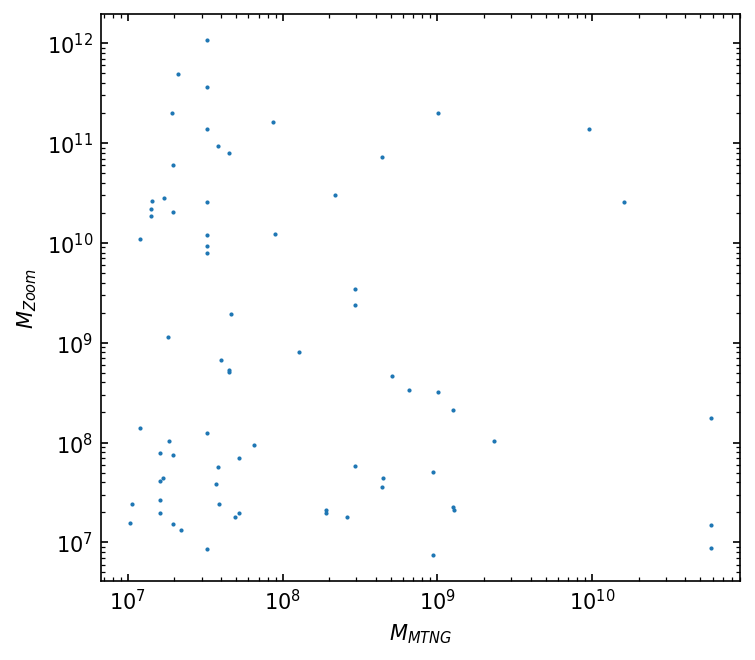

In [76]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(m_sub_mtng, m_sub_zoom, marker='o', ls='', ms=1)

ax.set_xlabel('$M_{MTNG}$')
ax.set_ylabel('$M_{Zoom}$')

### Cross-match FoF groups in the two

In [78]:
zoom_sel = np.where(zoom.fof['halo_m200b']!=0)
mtng_sel = np.where(mtng.fof['halo_m200b']!=0)

In [79]:
dist, ind = bacco.utils.crossmatch(zoom.fof['halo_pos'][zoom_sel], mtng.fof['halo_pos'][mtng_sel], max_distance=0.1, boxsize=500.000001)

In [80]:
# clean the 
i_clean = np.where(dist!=np.inf)

In [81]:
m_zoom = 1e10 * zoom.fof['halo_m200b'][zoom_sel][i_clean]
m_mtng = 1e10 * mtng.fof['halo_m200b'][mtng_sel][ind[i_clean]]

Text(0, 0.5, '$M_{Zoom}$')

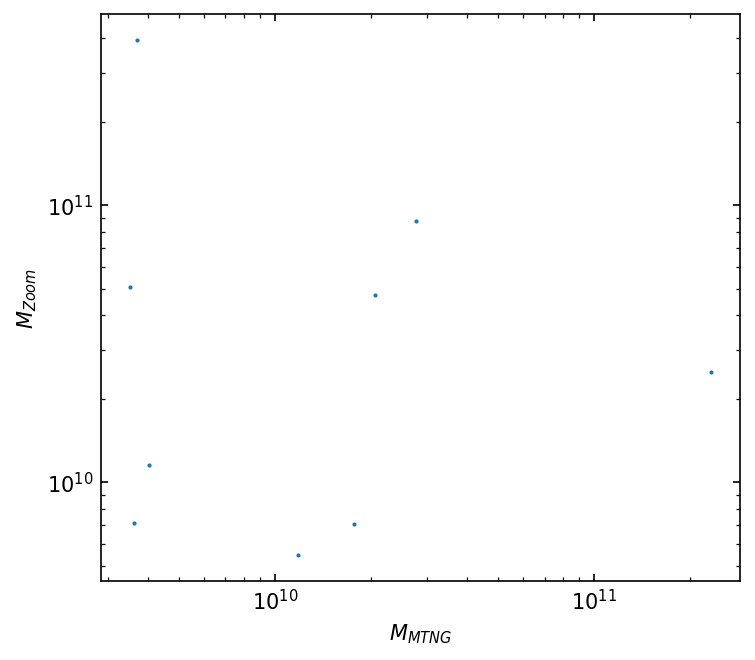

In [82]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(m_mtng, m_zoom, marker='o', ls='', ms=1)

ax.set_xlabel('$M_{MTNG}$')
ax.set_ylabel('$M_{Zoom}$')